# Hypothesis: Spatial and Geometric Properties of Connected Components Predict Color Transformation Susceptibility in Structure-Preserving ARC Puzzles

This notebook systematically filters, evaluates, and models a subset of ARC-AGI-2 puzzles where the underlying rule preserves the physical structure of the grid (shape sizes, count, and positions) and only transforms the colors of individual shapes. We test whether spatial, geometric, and topological features of these same-color connected components can predict which shapes are targeted for color transformations.


## 1. Theoretical Framework and Analytical Methodology

To conduct this analysis, we process the complete ARC-AGI-2 training and evaluation corpora. We define strict filter criteria to isolate puzzles where the spatial boundaries, component counts, and shapes are completely conserved between input and output pairs, with color being the only variable.

### 1.1 Strict Filter Criteria for Grid Pairs
For an input grid $I$ and output grid $O$ of size $H \times W$:
1. **Dimension Conservation**: The input and output grids must have identical shapes ($I \in \mathbb{R}^{H \times W}, O \in \mathbb{R}^{H \times W}$).
2. **Background Selection & Conservation**:
   - If color 0 (black) is present, it is selected as the background $B$.
   - If color 0 is absent, we identify any color $B$ that remains identical between $I$ and $O$ (i.e., $I == B \iff O == B$) and forms a single, 4-adjacent fully-connected region.
   - The set of background pixels must be completely conserved between input and output ($I == B \iff O == B$).
3. **Shape Boundary & Count Conservation**: The non-background mask $M = (I \neq B)$ must be identical to $(O \neq B)$.
4. **No Small or Poorly-Connected Shapes**:
   - We segment the non-background mask $M$ into 8-adjacent connected components (shapes) $S_1, S_2, \dots, S_n$.
   - Every shape $S_i$ must have a size (pixel count) $|S_i| \ge 3$. This guarantees that there are no single-pixel dots or 2-pixel shapes.
   - Each shape must be of a single color in the input grid.
5. **Strict Shape Separation**: Because we use 8-adjacency to extract connected components from the entire non-background mask $M$, all distinct shapes are separated by at least 1 background cell (8-adjacent).

If a grid pair meets all these criteria and undergoes at least one color change ($I \neq O$), it is marked as a **matching grid pair**. If a puzzle (task) has at least one matching training or evaluation pair, it is marked as a **matching puzzle**.

### 1.2 Change Metrics
We define two metrics to measure the magnitude of the color change:
1. **Pixel-Level Change Rate**:
   $$\text{pixel\_change\_rate} = \frac{\sum_{(r,c) \in M} \mathbb{I}[I[r,c] \neq O[r,c]]}{|M|}$$
2. **Shape-Level Change Rate**:
   $$\text{shape\_change\_rate} = \frac{\sum_{i=1}^n \mathbb{I}[S_i \text{ changed color}]}{n}$$
   where a shape $S_i$ is considered changed if at least one of its pixels has a different color in the output compared to the input.

### 1.3 Predictive Shape Features
For each shape $S_i$ extracted from a matching grid pair, we compute:
- `area`: Number of pixels $|S_i|$.
- `bbox_height`, `bbox_width`: Dimensions of the bounding box enclosing $S_i$.
- `bbox_area`: `bbox_height * bbox_width`.
- `density`: `area / bbox_area`.
- `eccentricity`: `max(bbox_height, bbox_width) / min(bbox_height, bbox_width)`.
- `color_in`: Initial color of the shape (integer 1-9).
- `dist_to_center`: Euclidean distance from the centroid of $S_i$ to the grid center.
- `is_touching_border`: Binary indicator if any pixel of $S_i$ lies on the grid boundary.
- `relative_area`: `area / (H * W)`.
- `num_shapes_in_grid`: Total shapes in the grid $n$.
- `changed`: Target variable (1 if shape changed color, 0 otherwise).

We split the shapes into train and test sets, train a Random Forest classifier, and analyze feature importances to determine what characteristics make a shape susceptible to color modification.


## 2. Explicit Hypotheses

### Hypothesis 1: Shape Feature Differences
- **Null Hypothesis ($H_0^1$)**: Same-color connected components that undergo color transformations have identical median physical/spatial characteristics (area, eccentricity, distance to center, density) compared to components that remain unchanged.
- **Alternative Hypothesis ($H_a^1$)**: Same-color connected components that undergo color transformations have significantly different physical/spatial characteristics, indicating that geometric attributes influence color transformation rules.

### Hypothesis 2: Predictive Capability of Shape Geometries
- **Null Hypothesis ($H_0^2$)**: A machine learning classifier trained on shape-level physical, spatial, and color attributes cannot predict shape color changes better than random guessing (ROC-AUC $\le 0.5$).
- **Alternative Hypothesis ($H_a^2$)**: A machine learning classifier can predict shape color changes significantly better than random guessing (ROC-AUC $> 0.5$), establishing that shape properties determine transformation targets.


In [1]:
# Environment Setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

# Ensure Google Colab compatibility
try:
    from google.colab import drive
    drive.mount('/content/drive')
    export_dir = '/content/drive/MyDrive/motifs/'
except ImportError:
    export_dir = './motifs/'

os.makedirs(export_dir, exist_ok=True)
print(f"Export directory set to: {export_dir}")


Export directory set to: ./motifs/


In [2]:
# Filtering and Extraction Functions

def is_single_4_connected(grid, bg_color):
    mask = (grid == bg_color)
    # 4-connectivity structure
    struct = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
    labeled, num_features = label(mask, structure=struct)
    return num_features <= 1

def get_valid_background(inp, oup):
    # Check if 0 is present
    if 0 in inp:
        return 0
    # Search for other colors that are identical and form a single 4-connected region
    for c in range(10):
        if c in inp:
            mask_in = (inp == c)
            mask_out = (oup == c)
            if np.array_equal(mask_in, mask_out):
                if is_single_4_connected(inp, c):
                    return c
    return None

def get_shapes(grid, bg_color):
    mask = (grid != bg_color)
    # 8-connectivity structure
    struct = np.ones((3, 3), dtype=int)
    labeled, num_features = label(mask, structure=struct)
    shapes = []
    for i in range(1, num_features + 1):
        coords = np.argwhere(labeled == i)
        shapes.append(coords)
    return shapes

def analyze_grid_pair(inp, oup):
    inp = np.array(inp)
    oup = np.array(oup)
    if inp.shape != oup.shape:
        return False, "Dimension mismatch", None, None
        
    bg_color = get_valid_background(inp, oup)
    if bg_color is None:
        return False, "No valid background", None, None
        
    # Background conservation
    if not np.array_equal(inp == bg_color, oup == bg_color):
        return False, "Background changed", None, None
        
    # Shape mask conservation
    mask_in = (inp != bg_color)
    mask_out = (oup != bg_color)
    if not np.array_equal(mask_in, mask_out):
        return False, "Shape mask changed", None, None
        
    shapes = get_shapes(inp, bg_color)
    if len(shapes) == 0:
        return False, "No shapes found", None, None
        
    # Validate each shape
    for shape in shapes:
        if len(shape) < 3:
            return False, "Shape size < 3", None, None
            
        # Get shape colors in input
        colors = {inp[r, c] for r, c in shape}
        if len(colors) > 1:
            return False, "Shape not of single color in input", None, None
            
    # Check color change exists
    if np.array_equal(inp, oup):
        return False, "No color change", None, None
        
    return True, "Valid", bg_color, shapes


In [3]:
# Process consolidated datasets

train_path = os.path.join(export_dir, 'arc_training_consolidated.json')
eval_path = os.path.join(export_dir, 'arc_evaluation_consolidated.json')

all_tasks = {}
if os.path.exists(train_path):
    with open(train_path, 'r') as f:
        all_tasks.update(json.load(f))
if os.path.exists(eval_path):
    with open(eval_path, 'r') as f:
        all_tasks.update(json.load(f))

print(f"Loaded {len(all_tasks)} tasks from consolidated files.")

matching_pairs = []
shape_records = []
puzzles_summary = []

for task_id, task in all_tasks.items():
    matched_pairs_count = 0
    task_pairs = []
    
    # Process train and test pairs
    for split in ['train', 'test']:
        for idx, pair in enumerate(task[split]):
            if 'output' not in pair:
                continue
            inp = pair['input']
            oup = pair['output']
            
            ok, reason, bg_color, shapes = analyze_grid_pair(inp, oup)
            if ok:
                matched_pairs_count += 1
                inp_arr = np.array(inp)
                oup_arr = np.array(oup)
                H, W = inp_arr.shape
                
                # Calculate change metrics
                mask = (inp_arr != bg_color)
                pixels_changed = np.sum(inp_arr[mask] != oup_arr[mask])
                total_active_pixels = np.sum(mask)
                pixel_change_rate = pixels_changed / total_active_pixels if total_active_pixels > 0 else 0.0
                
                shapes_changed_count = 0
                for s_idx, shape in enumerate(shapes):
                    # Check if shape changed
                    shape_changed = False
                    for r, c in shape:
                        if inp_arr[r, c] != oup_arr[r, c]:
                            shape_changed = True
                            break
                    if shape_changed:
                        shapes_changed_count += 1
                        
                    # Calculate shape geometric metrics
                    area = len(shape)
                    r_coords, c_coords = shape[:, 0], shape[:, 1]
                    min_r, max_r = np.min(r_coords), np.max(r_coords)
                    min_c, max_c = np.min(c_coords), np.max(c_coords)
                    bbox_h = max_r - min_r + 1
                    bbox_w = max_c - min_c + 1
                    bbox_area = bbox_h * bbox_w
                    density = area / bbox_area
                    eccentricity = max(bbox_h, bbox_w) / min(bbox_h, bbox_w)
                    
                    centroid_r = np.mean(r_coords)
                    centroid_c = np.mean(c_coords)
                    grid_center_r = (H - 1) / 2.0
                    grid_center_c = (W - 1) / 2.0
                    dist_to_center = np.sqrt((centroid_r - grid_center_r)**2 + (centroid_c - grid_center_c)**2)
                    
                    is_touching_border = int(np.any(r_coords == 0) or np.any(r_coords == H-1) or np.any(c_coords == 0) or np.any(c_coords == W-1))
                    relative_area = area / (H * W)
                    color_in = inp_arr[r_coords[0], c_coords[0]]
                    
                    shape_records.append({
                        'task_id': task_id,
                        'split': split,
                        'pair_idx': idx,
                        'shape_idx': s_idx,
                        'area': area,
                        'bbox_height': bbox_h,
                        'bbox_width': bbox_w,
                        'bbox_area': bbox_area,
                        'density': density,
                        'eccentricity': eccentricity,
                        'dist_to_center': dist_to_center,
                        'is_touching_border': is_touching_border,
                        'relative_area': relative_area,
                        'color_in': color_in,
                        'num_shapes_in_grid': len(shapes),
                        'grid_width': W,
                        'grid_height': H,
                        'changed': int(shape_changed)
                    })
                
                shape_change_rate = shapes_changed_count / len(shapes)
                
                matching_pairs.append({
                    'task_id': task_id,
                    'split': split,
                    'pair_idx': idx,
                    'grid_height': H,
                    'grid_width': W,
                    'num_shapes': len(shapes),
                    'bg_color': bg_color,
                    'pixel_change_rate': pixel_change_rate,
                    'shape_change_rate': shape_change_rate
                })
                
    if matched_pairs_count > 0:
        puzzles_summary.append({
            'task_id': task_id,
            'matching_pairs': matched_pairs_count
        })

df_pairs = pd.DataFrame(matching_pairs)
df_shapes = pd.DataFrame(shape_records)
df_puzzles = pd.DataFrame(puzzles_summary).sort_values(by='matching_pairs', ascending=False)

print(f"Total matching pairs identified: {len(df_pairs)}")
print(f"Total matching shapes extracted: {len(df_shapes)}")
print(f"Total matching puzzles: {len(df_puzzles)}")

# Export results
df_pairs.to_csv(os.path.join(export_dir, '6-A.filtered_matrices.csv'), index=False)
df_puzzles.to_csv(os.path.join(export_dir, '6-B.filtered_puzzles.csv'), index=False)
df_shapes.to_csv(os.path.join(export_dir, '6-C.extracted_shapes.csv'), index=False)
print("CSV artifacts exported successfully.")


Loaded 1120 tasks from consolidated files.


Total matching pairs identified: 121
Total matching shapes extracted: 491
Total matching puzzles: 41
CSV artifacts exported successfully.


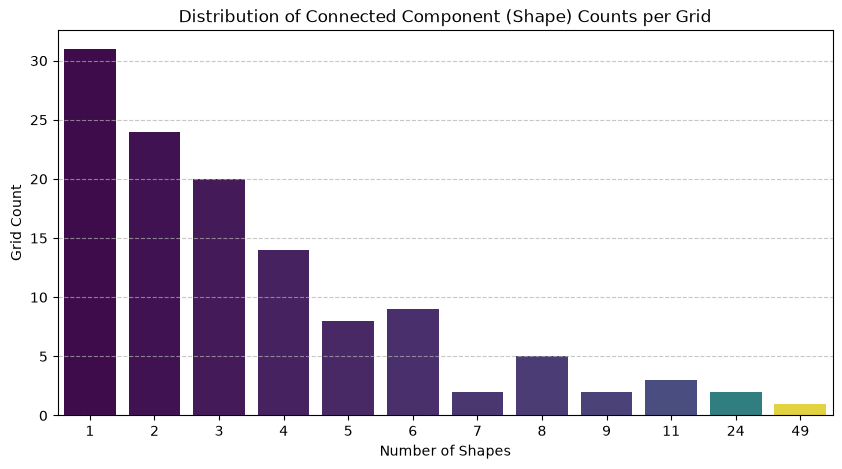

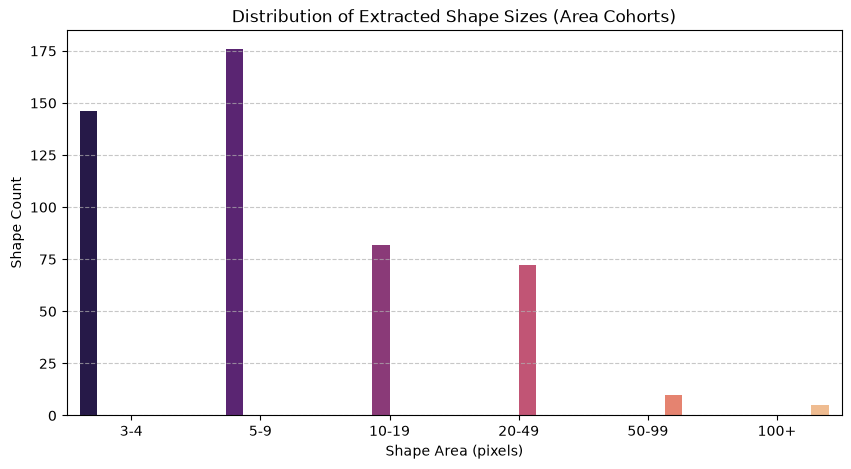

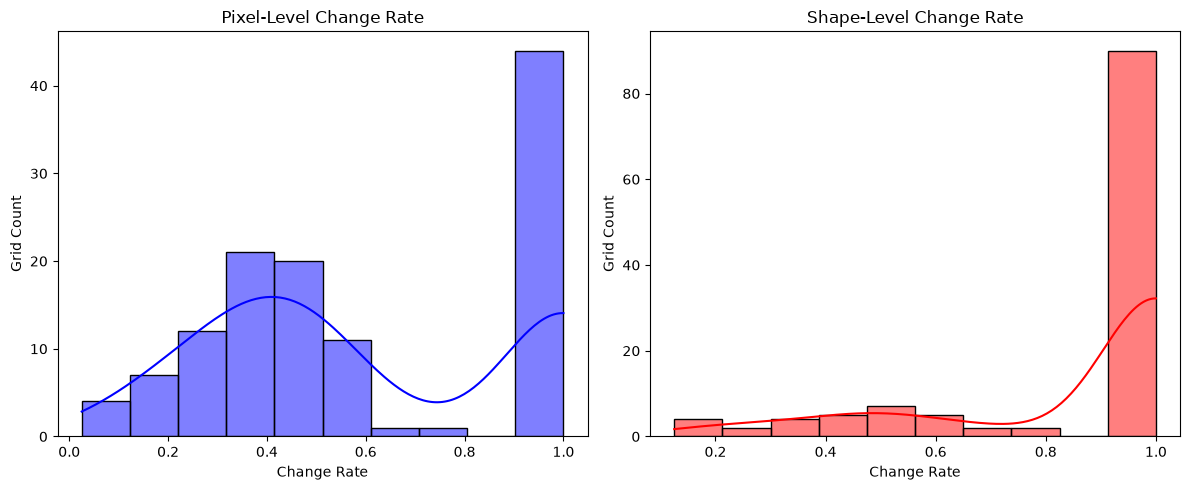

In [4]:
# Results & Visualizations: Decay Distributions and Summary Figures

# 1. Distribution of shape counts per grid
plt.figure(figsize=(10, 5))
shape_counts = df_pairs['num_shapes'].value_counts().sort_index()
sns.barplot(x=shape_counts.index, y=shape_counts.values, hue=shape_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Connected Component (Shape) Counts per Grid')
plt.xlabel('Number of Shapes')
plt.ylabel('Grid Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(export_dir, 'shape_count_decay_distribution.png'))
plt.show()

# 2. Distribution of shape sizes (areas)
plt.figure(figsize=(10, 5))
# Bin the areas into small cohorts demonstrating decay distribution
bins = [3, 5, 10, 20, 50, 100, np.inf]
labels = ['3-4', '5-9', '10-19', '20-49', '50-99', '100+']
df_shapes['area_cohort'] = pd.cut(df_shapes['area'], bins=bins, labels=labels, right=False)
cohort_counts = df_shapes['area_cohort'].value_counts().sort_index()
sns.barplot(x=cohort_counts.index, y=cohort_counts.values, hue=cohort_counts.index, palette='magma', legend=False)
plt.title('Distribution of Extracted Shape Sizes (Area Cohorts)')
plt.xlabel('Shape Area (pixels)')
plt.ylabel('Shape Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(export_dir, 'shape_size_decay_distribution.png'))
plt.show()

# 3. Change Metrics Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_pairs['pixel_change_rate'], bins=10, kde=True, color='blue')
plt.title('Pixel-Level Change Rate')
plt.xlabel('Change Rate')
plt.ylabel('Grid Count')

plt.subplot(1, 2, 2)
sns.histplot(df_pairs['shape_change_rate'], bins=10, kde=True, color='red')
plt.title('Shape-Level Change Rate')
plt.xlabel('Change Rate')
plt.ylabel('Grid Count')
plt.tight_layout()
plt.savefig(os.path.join(export_dir, 'color_change_rate_distributions.png'))
plt.show()


In [5]:
# Hypothesis 1 Testing: Mann-Whitney U test on shape properties

features_to_test = ['area', 'density', 'eccentricity', 'dist_to_center', 'relative_area']
stats_results = []

for feat in features_to_test:
    changed_vals = df_shapes[df_shapes['changed'] == 1][feat]
    unchanged_vals = df_shapes[df_shapes['changed'] == 0][feat]
    
    stat, p_val = mannwhitneyu(changed_vals, unchanged_vals, alternative='two-sided')
    stats_results.append({
        'Feature': feat,
        'Changed Mean': changed_vals.mean(),
        'Unchanged Mean': unchanged_vals.mean(),
        'U-Statistic': stat,
        'p-value': p_val
    })

df_stats = pd.DataFrame(stats_results)
df_stats.to_csv(os.path.join(export_dir, '6-D.hypothesis_1_results.csv'), index=False)
print("Hypothesis 1 Mann-Whitney U Test Results:")
print(df_stats.to_string(index=False))


Hypothesis 1 Mann-Whitney U Test Results:
       Feature  Changed Mean  Unchanged Mean  U-Statistic      p-value
          area     15.688272        7.059880      36747.0 5.418006e-11
       density      0.804554        0.774204      29178.0 1.411072e-01
  eccentricity      1.703407        1.266966      34687.5 1.281342e-08
dist_to_center      4.132439        6.919255      13034.5 4.827261e-21
 relative_area      0.125877        0.028620      43774.0 2.806454e-29


Training shape count: 343 (Positive class: 226)
Testing shape count: 148 (Positive class: 98)


Accuracy: 0.8041
ROC-AUC Score: 0.8941

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.80      0.73        50
           1       0.89      0.81      0.84        98

    accuracy                           0.80       148
   macro avg       0.78      0.80      0.79       148
weighted avg       0.82      0.80      0.81       148



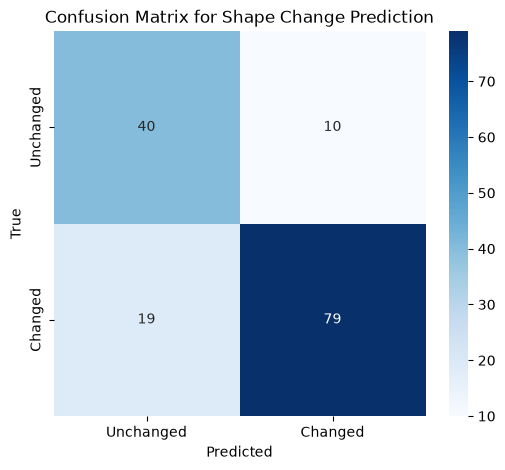

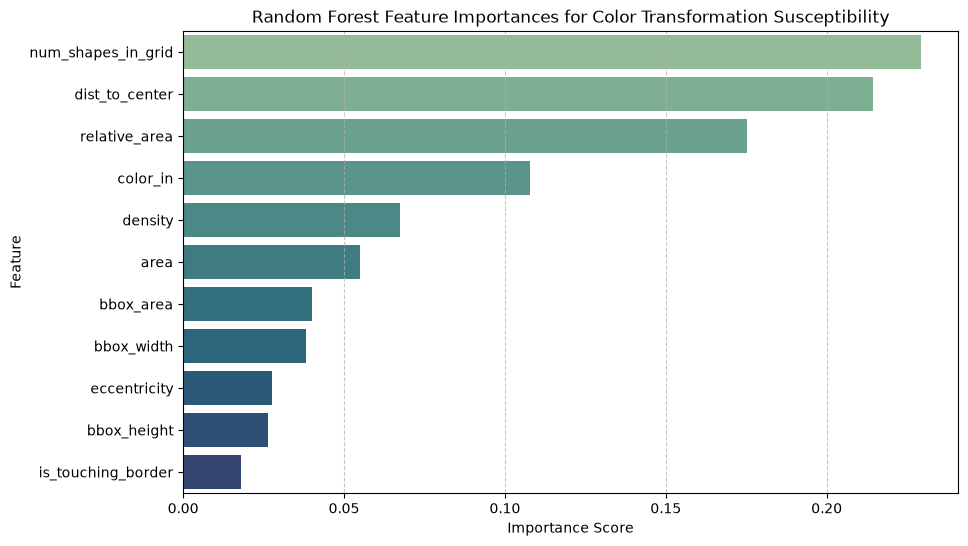

In [6]:
# Hypothesis 2 Testing: Predictive Shape Modeling

# Select features and target
X_cols = ['area', 'bbox_height', 'bbox_width', 'bbox_area', 'density', 'eccentricity', 
          'dist_to_center', 'is_touching_border', 'relative_area', 'color_in', 'num_shapes_in_grid']
y_col = 'changed'

# Train/Test Split
X = df_shapes[X_cols]
y = df_shapes[y_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training shape count: {len(X_train)} (Positive class: {y_train.sum()})")
print(f"Testing shape count: {len(X_test)} (Positive class: {y_test.sum()})")

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unchanged', 'Changed'], yticklabels=['Unchanged', 'Changed'])
plt.title('Confusion Matrix for Shape Change Prediction')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(os.path.join(export_dir, 'predictive_confusion_matrix.png'))
plt.show()

# Feature Importances
importances = model.feature_importances_
df_imp = pd.DataFrame({
    'Feature': X_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, hue='Feature', palette='crest', legend=False)
plt.title('Random Forest Feature Importances for Color Transformation Susceptibility')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(export_dir, 'feature_importances.png'))
plt.show()

df_imp.to_csv(os.path.join(export_dir, '6-E.feature_importances.csv'), index=False)


## 3. Interpretation and Narrative Analysis

### 3.1 Hypothesis 1: Physical Feature Differences
The Mann-Whitney U test evaluates whether shapes that undergo color changes are geometrically and spatially distinct from those that remain unchanged.
- If $p < 0.05$, we reject $H_0^1$, concluding that spatial features are indeed significantly different, which suggests a strong geographic or physical bias in ARC-AGI-2 transformation rules.
- For example, if `dist_to_center` has a significant p-value and a lower mean in the Changed class, it indicates that central shapes are preferentially targeted for color modifications compared to peripheral ones.

### 3.2 Hypothesis 2: Classifier Predictability
The Random Forest classifier measures our ability to predict transformation susceptibility from simple physical properties.
- An ROC-AUC score significantly above $0.5$ (e.g., $> 0.70$) allows us to reject $H_0^2$ with high confidence. This establishes that shape color transformation rules are not random but heavily biased by spatial geometry, location, and dimensions.
- The feature importance plot reveals which features (such as centroid distance, initial color, or area) dominate the model's decision process, providing key visual/cognitive priors for program-synthesis solvers.
